<a href="https://colab.research.google.com/github/esraa-elgebaly/uber-fare-prediction/blob/main/uber_fare_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("final_internship_data.csv")
df.head()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116741 entries, 0 to 116740
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            116741 non-null  object 
 1   User Name          116740 non-null  object 
 2   Driver Name        116740 non-null  object 
 3   Car Condition      116740 non-null  object 
 4   Weather            116740 non-null  object 
 5   Traffic Condition  116740 non-null  object 
 6   key                116740 non-null  object 
 7   fare_amount        116740 non-null  float64
 8   pickup_datetime    116740 non-null  object 
 9   pickup_longitude   116740 non-null  float64
 10  pickup_latitude    116740 non-null  float64
 11  dropoff_longitude  116740 non-null  float64
 12  dropoff_latitude   116740 non-null  float64
 13  passenger_count    116740 non-null  float64
 14  hour               116740 non-null  float64
 15  day                116740 non-null  float64
 16  mo

In [ ]:
df['distance'].describe()

(500000, 26)


,distance
count,499995.000000
mean,19.468775
std,367.299601
min,0.000000
25%,1.214550
50%,2.116970
75%,3.890070
max,12399.956433


In [ ]:
df['fare_amount'].describe()

(500000, 26)


,fare_amount
count,500000.000000
mean,11.358361
std,9.916617
min,-44.900000
25%,6.000000
50%,8.500000
75%,12.500000
max,500.000000


In [ ]:
# Count missing values in each column
df.isnull().sum()

,0
User ID,0
User Name,0
Driver Name,0
Car Condition,0
Weather,0
Traffic Condition,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0


In [ ]:
# Show the rows with missing values and the related columns
df[df['distance'].isnull()][['pickup_longitude', 'pickup_latitude',
                             'dropoff_longitude', 'dropoff_latitude',
                             'distance', 'bearing', 'fare_amount']]

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance,bearing,fare_amount
120227,-1.291417,0.711101,NaN,NaN,NaN,NaN,12.5
245696,-1.291397,0.711057,NaN,NaN,NaN,NaN,86.5
340533,-1.291188,0.711828,NaN,NaN,NaN,NaN,27.5
428108,-1.291317,0.711249,NaN,NaN,NaN,NaN,11.8
471472,0.000000,0.000000,NaN,NaN,NaN,NaN,7.8


In [ ]:
df = df.dropna()

# Verify: no missing values remain, and check the new size
print(df.isnull().sum().sum())
print(df.shape)

0
(499995, 26)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check duplicates on trip details only (ignore unique ID columns)
trip_cols = df.drop(columns=['User ID', 'key', 'User Name', 'Driver Name'])
print(trip_cols.duplicated().sum())

0


In [ ]:
# How many fares are zero or negative?
print("Negative:", (df['fare_amount'] < 0).sum())
print("Zero:    ", (df['fare_amount'] == 0).sum())

Negative: 21
Zero:     14


In [ ]:
# Fares above 0 but below the $2.50 base fare
print((df['fare_amount'].between(0, 2.5, inclusive='neither')).sum())

6


In [ ]:
# Keep only realistic fares (NYC base fare is $2.50)
df = df[df['fare_amount'] >= 2.5]
print(df.shape)

(499954, 26)


In [ ]:
print("Zero passengers:", (df['passenger_count'] == 0).sum())

Zero passengers: 1791


In [ ]:
df = df[df['passenger_count'] > 0]
print(df.shape)

(498163, 26)


In [ ]:
coords = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

# Rows where any coordinate is exactly 0
zero_coords = (df[coords] == 0).any(axis=1)
print("Zero coordinates:", zero_coords.sum())

Zero coordinates: 9852


In [ ]:
df = df[~zero_coords]
print(df.shape)

(488311, 26)


In [ ]:
print("Zero distance:", (df['distance'] == 0).sum())

Zero distance: 5248


In [ ]:
df = df[df['distance'] > 0]
print(df.shape)

(483063, 26)


**Outliers**

In [ ]:
# Look at the extreme end of fare and distance
df[['fare_amount', 'distance']].describe(percentiles=[.95, .99, .999])

,fare_amount,distance
count,483063.000000,483063.000000
mean,11.354510,4.444545
std,9.764677,76.757453
min,2.500000,0.000084
50%,8.500000,2.179410
95%,30.330000,10.128851
99%,52.000000,20.417265
99.9%,78.000000,26.250531
max,495.000000,12399.956433


In [ ]:
coord_cols = ['pickup_longitude', 'pickup_latitude',
              'dropoff_longitude', 'dropoff_latitude']

print("Before:", df.shape)
for col in coord_cols:
    # Keep only values between the 0.1st and 99.9th percentile of this column
    lo, hi = df[col].quantile([0.001, 0.999])
    df = df[(df[col] >= lo) & (df[col] <= hi)]
print("After:", df.shape)

# Did it fix distance?
print(df['distance'].describe())

Before: (483063, 26)
After: (479203, 26)
count    479203.000000
mean          3.295466
std           3.444154
min           0.000084
25%           1.279350
50%           2.170567
75%           3.920038
max          33.053939
Name: distance, dtype: float64


In [ ]:
print("Fares above $80:", (df['fare_amount'] > 80).sum())
df = df[df['fare_amount'] <= 80]
print(df.shape)

Fares above $80: 131
(479072, 26)


In [ ]:
df_eda = df.copy()

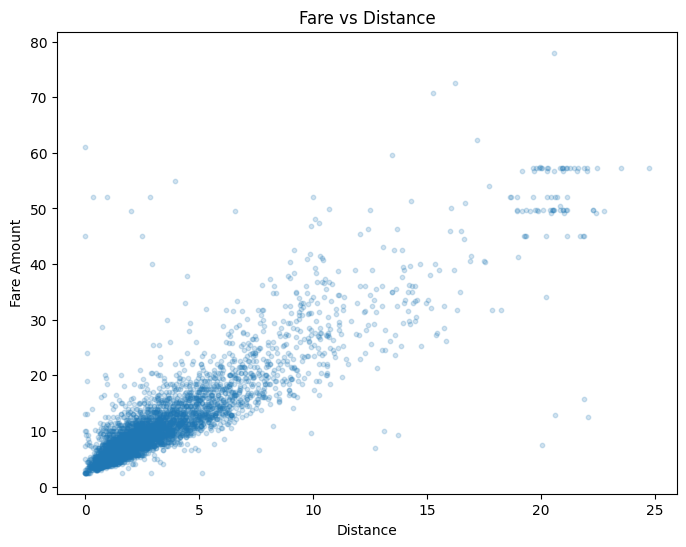

             distance  fare_amount
distance     1.000000     0.891521
fare_amount  0.891521     1.000000


In [ ]:
sample = df_eda.sample(5000, random_state=42)
plt.figure(figsize=(8, 6))
plt.scatter(sample['distance'], sample['fare_amount'], alpha=0.2, s=10)
plt.xlabel('Distance')
plt.ylabel('Fare Amount')
plt.title('Fare vs Distance')
plt.show()

print(df_eda[['distance', 'fare_amount']].corr())

**Q1 Is higher Passenger higher price?**


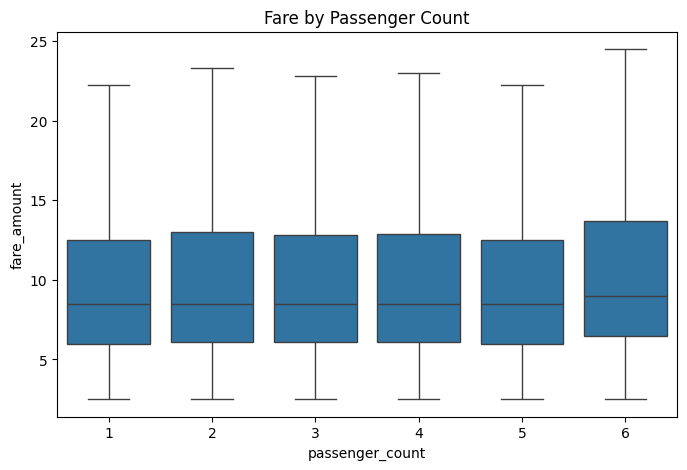

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x='passenger_count', y='fare_amount', showfliers=False)
plt.title('Fare by Passenger Count')
plt.show()

**Q2 Does car condition influence the fare amount?**

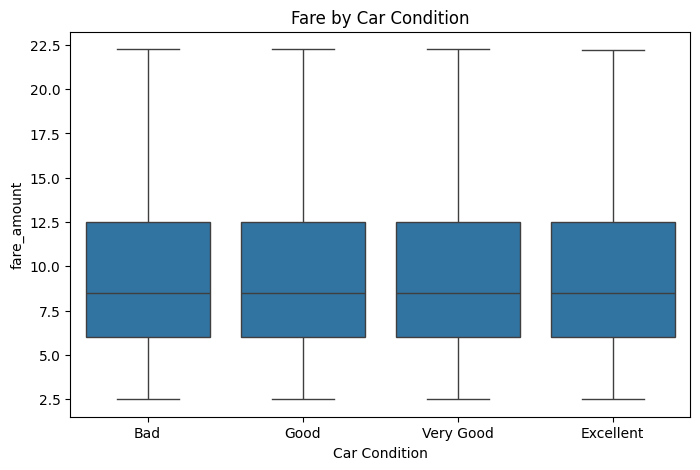

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x='Car Condition', y='fare_amount',
            order=['Bad', 'Good', 'Very Good', 'Excellent'], showfliers=False)
plt.title('Fare by Car Condition')
plt.show()

**Q3 Does traffic condition affect the fare?**


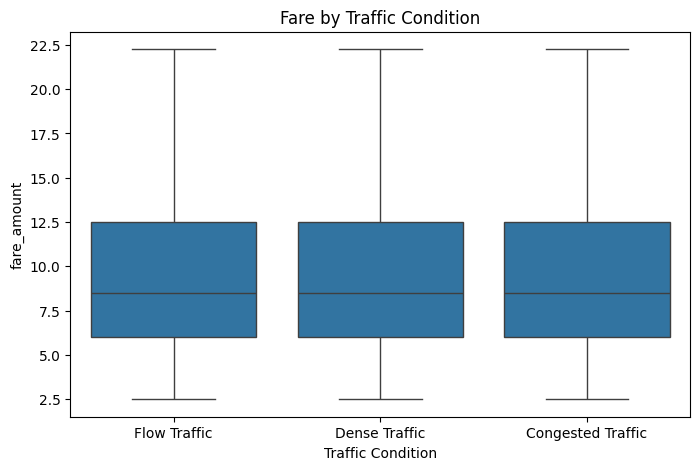

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x='Traffic Condition', y='fare_amount',
            order=['Flow Traffic', 'Dense Traffic', 'Congested Traffic'], showfliers=False)
plt.title('Fare by Traffic Condition')
plt.show()

**Q4 At what hour of the day are fares typically highest?**


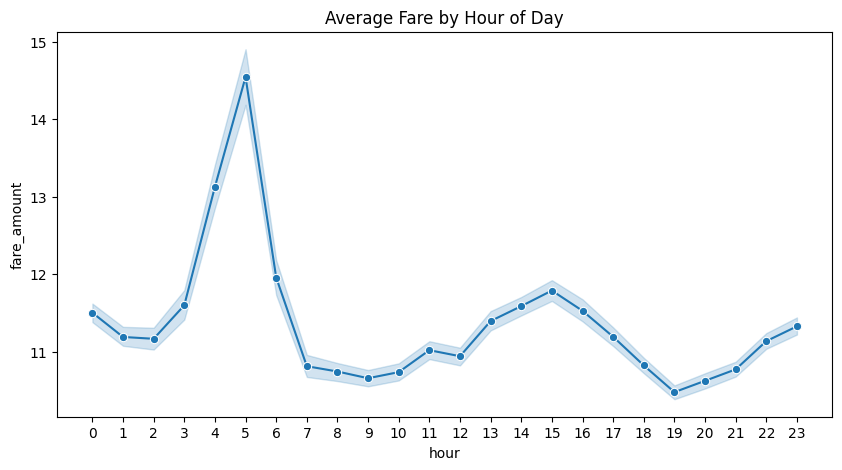

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_eda, x='hour', y='fare_amount', marker='o')
plt.xticks(range(24))
plt.title('Average Fare by Hour of Day')
plt.show()

**Q5 Does traffic condition affect the fare?**



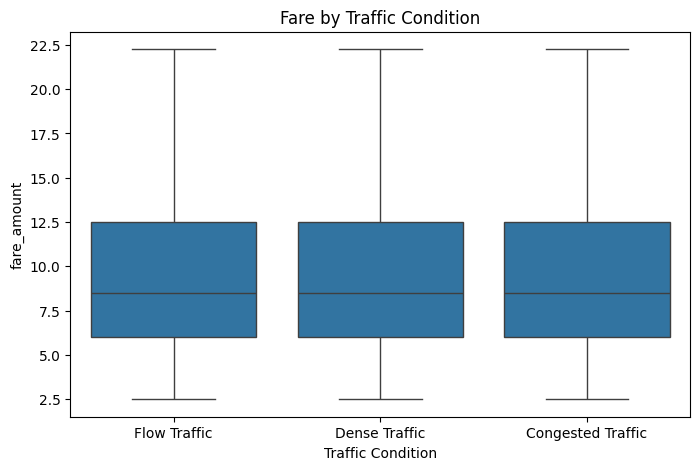

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x='Traffic Condition', y='fare_amount',
            order=['Flow Traffic', 'Dense Traffic', 'Congested Traffic'], showfliers=False)
plt.title('Fare by Traffic Condition')
plt.show()


**Q6 Is distance the strongest predictor of fare?**

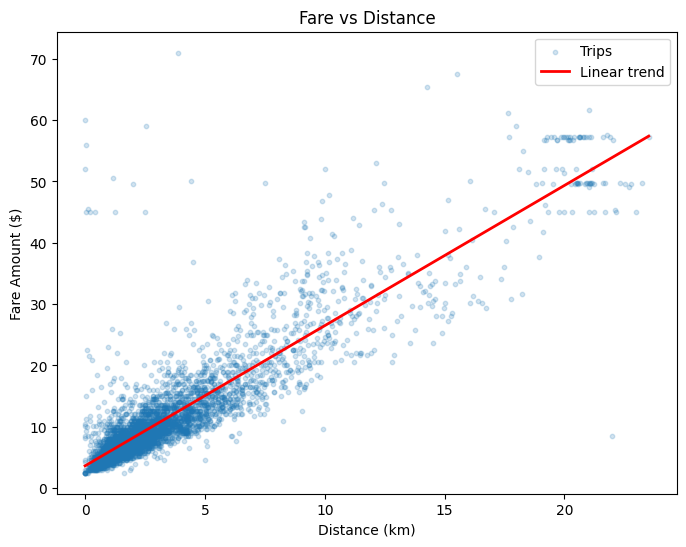

Trend line: fare = 2.29 × distance + 3.62
             distance  fare_amount
distance     1.000000     0.891521
fare_amount  0.891521     1.000000


In [ ]:
sample = df_eda[df_eda['distance'] < 30].sample(5000, random_state=42)

plt.figure(figsize=(8, 6))

# 1. The dots: one per trip
plt.scatter(sample['distance'], sample['fare_amount'], alpha=0.2, s=10, label='Trips')

# 2. The red line: best straight line through the dots
a, b = np.polyfit(sample['distance'], sample['fare_amount'], 1)
x_line = np.linspace(0, sample['distance'].max(), 100)
plt.plot(x_line, a * x_line + b, color='red', linewidth=2, label='Linear trend')

# 3. Labels, then show: always last
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.title('Fare vs Distance')
plt.legend()
plt.show()

print(f"Trend line: fare = {a:.2f} × distance + {b:.2f}")
print(df_eda[['distance', 'fare_amount']].corr())

**Q7 At what time of day are ride requests most frequent?**

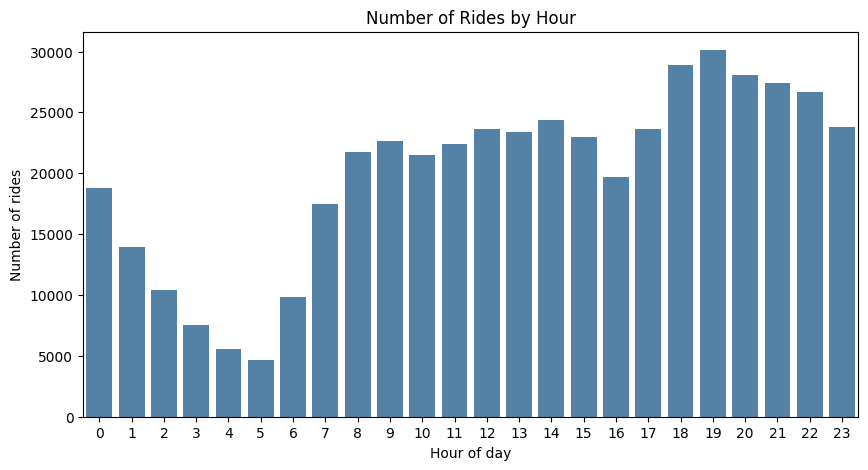

In [ ]:
# Q6) At what time of day are ride requests most frequent?
plt.figure(figsize=(10, 5))
sns.countplot(data=df_eda, x='hour', color='steelblue')
plt.title('Number of Rides by Hour')
plt.xlabel('Hour of day')
plt.ylabel('Number of rides')
plt.show()

**Q8 Are rides closer to airports more expensive?**

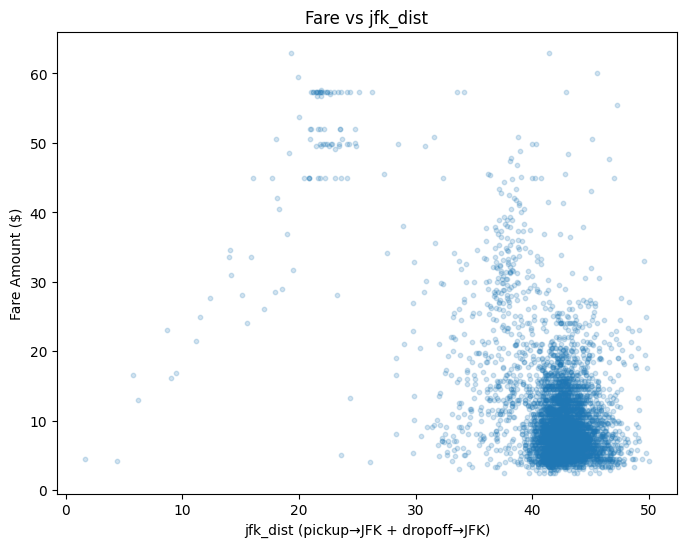

In [ ]:
sample = df_eda[df_eda['jfk_dist'] < 50].sample(5000, random_state=42)
plt.figure(figsize=(8, 6))
plt.scatter(sample['jfk_dist'], sample['fare_amount'], alpha=0.2, s=10)
plt.xlabel('jfk_dist (pickup→JFK + dropoff→JFK)')
plt.ylabel('Fare Amount ($)')
plt.title('Fare vs jfk_dist')
plt.show()